In [ ]:
import numpy as np
import pandas as pd

In [ ]:
class UserGenerator(object):
    def __init__(self):
        self.beta = {} # true model parameters we try to learn
        self.beta['A'] = np.array([-4, -0.1, -3, 0.1])
        self.beta['B'] = np.array([-6, -0.1, 1, 0.1])
        self.beta['C'] = np.array([2, 0.1, 1, -0.1])
        self.beta['D'] = np.array([4, 0.1, -3, -0.2])
        self.beta['E'] = np.array([-0.1, 0, 0.5, -0.01])
        self.context = None

    # logistic function
    def logistic(self, beta, context):
        f = np.dot(beta, context)
        p = 1 / (1 + np.exp(-f))
        return p

    # given ad, returns click info (reward)
    def display_ad(self, ad):
        if ad in ['A', 'B', 'C', 'D', 'E']:
            p = self.logistic(self.beta[ad], self.context)
            reward = np.random.binomial(n=1, p=p)
            return reward
        else:
            raise Exception('Unknown ad!')

    def generate_user_with_context(self):
        # 0: International, 1: U.S.
        location = np.random.binomial(n=1, p=0.6)
        # 0: Desktop, 1: Mobile
        device = np.random.binomial(n=1, p=0.8)
        # User age changes between 10 and 70,
        # with mean age 34
        age = 10 + int(np.random.beta(2, 3) * 60)
        # Add 1 to the concept for the intercept (bias term)
        self.context = [1, device, location, age]
        return self.context

In [ ]:
import matplotlib.pyplot as plt

def visualize_bandits(ug):
    ad_list = 'ABCDE'
    ages = np.linspace(10, 70)

    dashmap = {
        'A': 'solid',
        'B': 'dotted',
        'C': 'dashed',
        'D': 'dashdot',
        'E': (0, (5, 10))   # long dash
    }

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    fig.suptitle("Contextual Bandit Action Probabilities")

    titles = [
        "Desktop, International",
        "Desktop, U.S.",
        "Mobile, International",
        "Mobile, U.S."
    ]

    index = 0
    for device in [0, 1]:
        for loc in [0, 1]:
            ax = axes[device, loc]
            for ad in ad_list:
                probs = [ug.logistic(ug.beta[ad], [1, device, loc, age])
                         for age in ages]
                ax.plot(ages, probs, label=ad, linestyle=dashmap[ad])

            ax.set_title(titles[index])
            ax.set_xlabel("Age")
            ax.set_ylabel("CTR")
            index += 1

    # Only show legend once (like plotly version)
    axes[0, 0].legend(title="Ads")

    plt.tight_layout()
    plt.show()

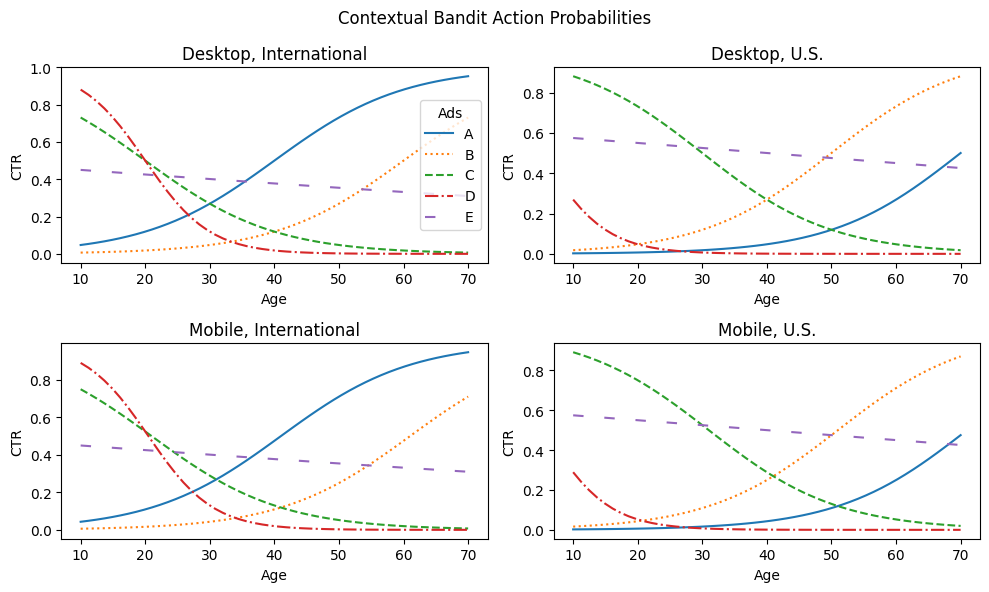

In [ ]:
ug = UserGenerator()
visualize_bandits(ug)

In [ ]:
# REGULARIZED LR

In [ ]:
from scipy.optimize import minimize

class RegularizedLR(object):
    def __init__(self, name, alpha, rlambda, n_dim):
        self.name = name
        self.alpha = alpha
        self.rlambda = rlambda
        self.n_dim = n_dim
        self.m = np.zeros(n_dim)
        self.q = np.ones(n_dim) * rlambda
        self.w = self.get_sampled_weights()

    def get_sampled_weights(self):
        w = np.random.normal(self.m, self.alpha * self.q**(-1/2))
        return w

    def loss(self, w, *args):
        X, y = args
        n = len(y)
        regularizer = 0.5 * np.dot(self.q, (w - self.m)**2)
        pred_loss = sum([np.log(1 + np.exp(np.dot(w, X[j])))
                                    - y[j] * np.dot(w, X[j]) for j in range(n)])
        return regularizer + pred_loss

    def fit(self, X, y):
        if y:
            X = np.array(X)
            y = np.array(y)
            minimization = minimize(self.loss,
                                    self.w,
                                    args=(X, y),
                                    method="L-BFGS-B",
                                    bounds=[(-10,10)]*3 + [(-1, 1)],
                                    options={'maxiter': 50})
            self.w = minimization.x
            self.m = self.w
            p = (1 + np.exp(-np.matmul(self.w, X.T)))**(-1)
            self.q = self.q + np.matmul(p * (1 - p), X**2)


    def calc_sigmoid(self, w, context):
        return 1 / (1 + np.exp(-np.dot(w, context)))

    def get_prediction(self, context):
        return self.calc_sigmoid(self.m, context)

    def sample_prediction(self, context):
        w = self.get_sampled_weights()
        return self.calc_sigmoid(w, context)

    def get_ucb(self, context):
        pred = self.calc_sigmoid(self.m, context)
        confidence = self.alpha * np.sqrt(np.sum(np.divide(np.array(context)**2, self.q)))
        ucb = pred + confidence
        return ucb

In [ ]:
def calculate_regret(ug, context, ad_options, ad):
    # 1. Compute true CTR values for all ads under this context
    action_values = {a: ug.logistic(ug.beta[a], context) for a in ad_options}

    # 2. Find the best possible ad (ground truth)
    best_action = max(action_values, key=action_values.get)

    # 3. Regret = best CTR - chosen CTR
    regret = action_values[best_action] - action_values[ad]

    return regret, best_action

In [ ]:
def select_ad_eps_greedy(ad_models, context, eps):
    if np.random.uniform() < eps:
        return np.random.choice(list(ad_models.keys()))
    else:
        predictions = {ad: ad_models[ad].get_prediction(context)
                       for ad in ad_models}
        max_value = max(predictions.values());
        max_keys = [key for key, value in predictions.items() if value == max_value] # for handling ties
        return np.random.choice(max_keys) # if multiple same values (tie), return random

In [ ]:
def select_ad_ucb(ad_models, context):
    ucbs = {ad: ad_models[ad].get_ucb(context)
                   for ad in ad_models}
    max_value = max(ucbs.values());
    max_keys = [key for key, value in ucbs.items() if value == max_value]
    return np.random.choice(max_keys)

In [ ]:
def select_ad_thompson(ad_models, context):
    samples = {ad: ad_models[ad].sample_prediction(context)
                   for ad in ad_models}
    max_value = max(samples.values());
    max_keys = [key for key, value in samples.items() if value == max_value]
    return np.random.choice(max_keys)

In [ ]:
ad_options = ['A', 'B', 'C', 'D', 'E']
exploration_data = {}
data_columns = ['context',
                'ad',
                'click',
                'best_action',
                'regret',
                'total_regret']
exploration_strategies = ['eps-greedy',
                          'ucb',
                          'Thompson']
# Start comparisons
for strategy in exploration_strategies:
    print("--- Now using", strategy)
    np.random.seed(0)
    # Create the LR models for each ad
    alpha, rlambda, n_dim = 0.5, 0.5, 4
    ad_models = {ad: RegularizedLR(ad,
                                   alpha,
                                   rlambda,
                                   n_dim)
                 for ad in 'ABCDE'}
    # Initialize data structures
    X = {ad: [] for ad in ad_options}
    y = {ad: [] for ad in ad_options}
    results = []
    total_regret = 0
    # Start ad display
    for i in range(10**4):
        context = ug.generate_user_with_context()
        if strategy == 'eps-greedy':
            eps = 0.1
            ad = select_ad_eps_greedy(ad_models,
                                      context,
                                      eps)
        elif strategy == 'ucb':
            ad = select_ad_ucb(ad_models, context)
        elif strategy == 'Thompson':
            ad = select_ad_thompson(ad_models, context)
        # Display the selected ad
        click = ug.display_ad(ad)
        # Store the outcome
        X[ad].append(context)
        y[ad].append(click)
        regret, best_action = calculate_regret(ug,
                                               context,
                                               ad_options,
                                               ad)
        total_regret += regret
        results.append((context,
                        ad,
                        click,
                        best_action,
                        regret,
                        total_regret))
        # Update the models with the latest batch of data
        if (i + 1) % 500 == 0:
            print("Updating the models at i:", i + 1)
            for ad in ad_options:
                ad_models[ad].fit(X[ad], y[ad])
            X = {ad: [] for ad in ad_options}
            y = {ad: [] for ad in ad_options}

    exploration_data[strategy] = {'models': ad_models,
                                  'results': pd.DataFrame(results,
                                                          columns=data_columns)}

--- Now using eps-greedy
Updating the models at i: 500
Updating the models at i: 1000
Updating the models at i: 1500
Updating the models at i: 2000
Updating the models at i: 2500
Updating the models at i: 3000
Updating the models at i: 3500
Updating the models at i: 4000
Updating the models at i: 4500
Updating the models at i: 5000
Updating the models at i: 5500
Updating the models at i: 6000
Updating the models at i: 6500
Updating the models at i: 7000
Updating the models at i: 7500
Updating the models at i: 8000
Updating the models at i: 8500
Updating the models at i: 9000
Updating the models at i: 9500
Updating the models at i: 10000
--- Now using ucb
Updating the models at i: 500
Updating the models at i: 1000
Updating the models at i: 1500
Updating the models at i: 2000
Updating the models at i: 2500
Updating the models at i: 3000
Updating the models at i: 3500
Updating the models at i: 4000
Updating the models at i: 4500
Updating the models at i: 5000
Updating the models at i: 55

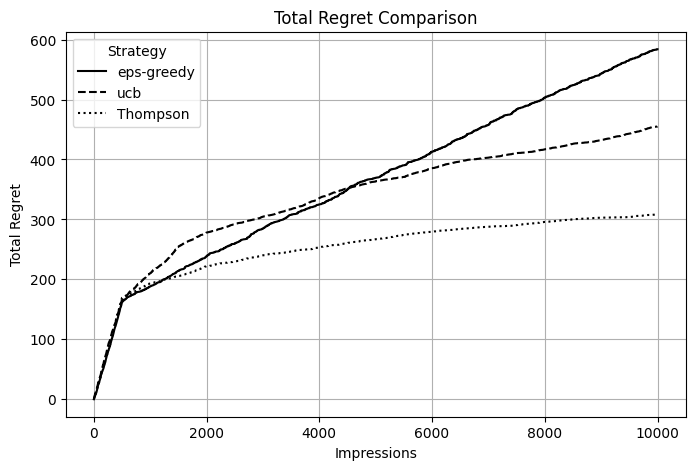

In [ ]:
import matplotlib.pyplot as plt

df_regret_comparisons = pd.DataFrame({s: exploration_data[s]['results'].total_regret
                                     for s in exploration_strategies})

# Simple line plot for all columns in df
df_regret_comparisons.plot(
    figsize=(8,5),
    style=['-', '--', ':'],  # line styles: solid, dashed, dotted
    color='black'            # all lines black
)

plt.xlabel('Impressions')
plt.ylabel('Total Regret')
plt.title('Total Regret Comparison')
plt.grid(True)
plt.legend(title='Strategy')
plt.show()


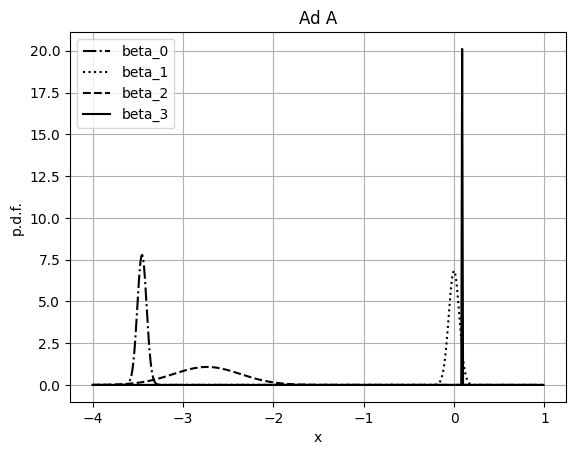

In [ ]:
from scipy import stats

lrmodel = exploration_data['eps-greedy']['models']['A']
df_beta_dist = pd.DataFrame([], index=np.arange(-4,1,0.01))
mean = lrmodel.m
std_dev = lrmodel.q ** (-1/2)

for i in range(lrmodel.n_dim):
    df_beta_dist['beta_'+str(i)] = stats.norm(loc=mean[i],
                                              scale=std_dev[i]).pdf(df_beta_dist.index)

# Define dash styles for each column
dash_styles = ['-.', ':', '--', '-']   # corresponds to dashdot, dot, dash, solid

# Plot each column with a different dashed style
for i, col in enumerate(df_beta_dist.columns):
    plt.plot(df_beta_dist.index, df_beta_dist[col],
             dash_styles[i % len(dash_styles)],
             color='black',
             label=col)

plt.xlabel('x')
plt.ylabel('p.d.f.')
plt.title('Ad A')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
for strategy in exploration_strategies:
    print(strategy)
    print(exploration_data[strategy]['models']['A'].m)
    print(exploration_data[strategy]['models']['B'].m)
    print(exploration_data[strategy]['models']['C'].m)
    print(exploration_data[strategy]['models']['D'].m)
    print(exploration_data[strategy]['models']['E'].m)

eps-greedy
[-3.45299027e+00 -5.96292581e-05 -2.73455057e+00  8.71960600e-02]
[-4.37485232 -0.32911028  1.26290912  0.06662901]
[ 2.29741141 -0.03689817  0.65960759 -0.09760303]
[ 1.93132158  1.26667212 -1.2303253  -0.18098702]
[ 0.11500113  0.21199604  0.71413982 -0.02646992]
ucb
[-1.98979004 -0.17175061 -2.53659527  0.05434809]
[-3.20772888 -0.19248636  0.72867587  0.05175552]
[ 0.59514679  1.14981912  0.92977165 -0.08515693]
[ 1.67800651  0.14563818 -1.97870212 -0.08844164]
[ 0.33276182 -0.09016569  0.64675957 -0.02369088]
Thompson
[-3.18810546e+00  3.09315609e-03 -2.46513866e+00  8.07015636e-02]
[-2.58790478  0.04554097  0.52013224  0.04196032]
[ 0.56532682  0.54274263  1.27558698 -0.07233646]
[ 2.52724229  0.44143238 -1.75879384 -0.13798083]
[-0.2597435   0.21582677  0.33789652 -0.00868178]


In [ ]:
# Function approximation for action - NN with bayesian approximation

In [ ]:
from collections import namedtuple
from numpy.random import uniform as U
import pandas as pd
import numpy as np
import io
import requests
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
url="https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
s=requests.get(url).content
names = ['age',
           'workclass',
           'fnlwgt',
           'education',
           'education_num',
           'marital_status',
           'occupation',
           'relationship',
           'race',
           'gender',
           'capital_gain',
           'capital_loss',
           'hours_per_week',
           'native_country',
          'income']
usecols = ['age',
           'workclass',
           'education',
           'marital_status',
           'occupation',
           'relationship',
           'race',
           'gender',
           'hours_per_week',
           'native_country',
           'income']
df_census = pd.read_csv(io.StringIO(s.decode('utf-8')),
                        sep=',',
                        skipinitialspace=True,
                        names=names,
                        header=None,
                        usecols=usecols)

In [ ]:
df_census.head()

,age,workclass,education,marital_status,occupation,relationship,race,gender,hours_per_week,native_country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K


In [ ]:
# Cleanup
df_census = df_census.replace('?', np.nan).dropna()
edu_map = {'Preschool': 'Elementary',
           '1st-4th': 'Elementary',
           '5th-6th': 'Elementary',
           '7th-8th': 'Elementary',
           '9th': 'Middle',
           '10th': 'Middle',
           '11th': 'Middle',
           '12th': 'Middle',
           'Some-college': 'Undergraduate',
           'Bachelors': 'Undergraduate',
           'Assoc-acdm': 'Undergraduate',
           'Assoc-voc': 'Undergraduate',
           'Prof-school': 'Graduate',
           'Masters': 'Graduate',
           'Doctorate': 'Graduate'}
# Assign the result of the replacement operation back to the 'education' column.
df_census['education'] = df_census['education'].replace(edu_map)

In [ ]:
df_census.head()

,age,workclass,education,marital_status,occupation,relationship,race,gender,hours_per_week,native_country,income
0,39,State-gov,Undergraduate,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K
1,50,Self-emp-not-inc,Undergraduate,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K
3,53,Private,Middle,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K
4,28,Private,Undergraduate,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K


In [ ]:
# Convert raw data to one-hot vectors to be able to fed into a DNN. We preserve the education column as is, since that is not part of the context
context_cols = [c for c in usecols if c != 'education']
df_data = pd.concat([pd.get_dummies(df_census[context_cols]),
           df_census['education']], axis=1)

In [ ]:
df_data.head()

,age,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital_status_Divorced,...,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia,income_<=50K,income_>50K,education
0,39,40,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,Undergraduate
1,50,13,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,True,False,Undergraduate
2,38,40,False,False,True,False,False,False,False,True,...,False,False,False,False,True,False,False,True,False,HS-grad
3,53,40,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,Middle
4,28,40,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,Undergraduate


In [ ]:
def get_ad_inventory():
    ad_inv_prob = {'Elementary': 0.9,
                   'Middle':  0.7,
                   'HS-grad':  0.7,
                   'Undergraduate':  0.9,
                   'Graduate':  0.8}
    ad_inventory = []
    for level, prob in ad_inv_prob.items():
        if U() < prob:
            ad_inventory.append(level)
    # Make sure there are at least one ad
    if not ad_inventory:
        ad_inventory = get_ad_inventory()
    return ad_inventory

In [ ]:
for i in range(10):
  print(get_ad_inventory())

['Elementary', 'Middle', 'HS-grad', 'Undergraduate', 'Graduate']
['Elementary', 'Middle', 'HS-grad', 'Undergraduate', 'Graduate']
['Elementary', 'Middle', 'HS-grad', 'Undergraduate', 'Graduate']
['Elementary', 'HS-grad', 'Undergraduate', 'Graduate']
['Middle', 'HS-grad', 'Graduate']
['Elementary', 'Middle', 'HS-grad', 'Undergraduate', 'Graduate']
['Elementary', 'Middle', 'HS-grad', 'Undergraduate', 'Graduate']
['Elementary', 'Middle', 'HS-grad', 'Undergraduate', 'Graduate']
['Elementary', 'HS-grad', 'Undergraduate', 'Graduate']
['Elementary', 'Middle', 'Undergraduate', 'Graduate']


In [ ]:
def get_ad_click_probs():
    base_prob = 0.8
    delta = 0.3
    ed_levels = {'Elementary': 1,
                 'Middle':  2,
                 'HS-grad':  3,
                 'Undergraduate':  4,
                 'Graduate':  5}
    ad_click_probs = {l1: {l2: max(0, base_prob - delta * abs(ed_levels[l1]- ed_levels[l2])) for l2 in ed_levels}
                           for l1 in ed_levels}
    return ad_click_probs

In [ ]:
get_ad_click_probs()

{'Elementary': {'Elementary': 0.8,
  'Middle': 0.5,
  'HS-grad': 0.20000000000000007,
  'Undergraduate': 0,
  'Graduate': 0},
 'Middle': {'Elementary': 0.5,
  'Middle': 0.8,
  'HS-grad': 0.5,
  'Undergraduate': 0.20000000000000007,
  'Graduate': 0},
 'HS-grad': {'Elementary': 0.20000000000000007,
  'Middle': 0.5,
  'HS-grad': 0.8,
  'Undergraduate': 0.5,
  'Graduate': 0.20000000000000007},
 'Undergraduate': {'Elementary': 0,
  'Middle': 0.20000000000000007,
  'HS-grad': 0.5,
  'Undergraduate': 0.8,
  'Graduate': 0.5},
 'Graduate': {'Elementary': 0,
  'Middle': 0,
  'HS-grad': 0.20000000000000007,
  'Undergraduate': 0.5,
  'Graduate': 0.8}}

In [ ]:
def display_ad(ad_click_probs, user, ad):
    prob = ad_click_probs[ad][user['education']]
    click = 1 if U() < prob else 0
    return click

In [ ]:
def calc_regret(user, ad_inventory, ad_click_probs, ad_selected):
    this_p = 0
    max_p = 0
    for ad in ad_inventory:
        p = ad_click_probs[ad][user['education']]
        if ad == ad_selected:
            this_p = p
        if p > max_p:
            max_p = p
    regret = max_p - this_p
    return regret

In [ ]:
# We create a function that returns a compiled DNN model with given input dimensions and a dropout rate

def get_model(n_input, dropout):
    inputs = keras.Input(shape=(n_input,))
    x = Dense(256, activation='relu')(inputs)
    if dropout > 0:
        x = Dropout(dropout)(x, training=True)
    x = Dense(256, activation='relu')(x)
    if dropout > 0:
        x = Dropout(dropout)(x, training=True)
    phat = Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, phat)
    model.compile(loss=keras.losses.BinaryCrossentropy(),
                  optimizer=keras.optimizers.Adam(),
                  metrics=[keras.metrics.binary_accuracy])
    return model

In [ ]:
def update_model(model, X, y):
    X = np.array(X)
    X = X.reshape((X.shape[0], X.shape[2]))
    y = np.array(y).reshape(-1)
    model.fit(X, y, epochs=10)
    return model

In [ ]:
def ad_to_one_hot(ad):
    ed_levels = ['Elementary',
                 'Middle',
                 'HS-grad',
                 'Undergraduate',
                 'Graduate']
    ad_input = [0] * len(ed_levels)
    if ad in ed_levels:
        ad_input[ed_levels.index(ad)] = 1
    return ad_input

In [ ]:
ad_to_one_hot('Undergraduate')

[0, 0, 0, 1, 0]

In [ ]:
# Thompson sampling to select an ad given the context and the ad inventory at hand

def select_ad(model, context, ad_inventory):
    selected_ad = None
    selected_x = None
    max_action_val = 0
    for ad in ad_inventory:
        ad_x = ad_to_one_hot(ad)
        x = np.array(context + ad_x).reshape((1, -1))
        action_val_pred = model.predict(x, verbose=0)[0][0]
        if action_val_pred >= max_action_val:
            selected_ad = ad
            selected_x = x
            max_action_val = action_val_pred
    return selected_ad, selected_x

In [ ]:
def generate_user(df_data):
    user = df_data.sample(1)
    context = user.iloc[:, :-1].values.tolist()[0]
    return user.to_dict(orient='records')[0], context

In [ ]:
generate_user(df_data)

({'age': 55,
  'hours_per_week': 50,
  'workclass_Federal-gov': False,
  'workclass_Local-gov': False,
  'workclass_Private': False,
  'workclass_Self-emp-inc': False,
  'workclass_Self-emp-not-inc': True,
  'workclass_State-gov': False,
  'workclass_Without-pay': False,
  'marital_status_Divorced': False,
  'marital_status_Married-AF-spouse': False,
  'marital_status_Married-civ-spouse': True,
  'marital_status_Married-spouse-absent': False,
  'marital_status_Never-married': False,
  'marital_status_Separated': False,
  'marital_status_Widowed': False,
  'occupation_Adm-clerical': False,
  'occupation_Armed-Forces': False,
  'occupation_Craft-repair': False,
  'occupation_Exec-managerial': False,
  'occupation_Farming-fishing': False,
  'occupation_Handlers-cleaners': False,
  'occupation_Machine-op-inspct': False,
  'occupation_Other-service': False,
  'occupation_Priv-house-serv': False,
  'occupation_Prof-specialty': False,
  'occupation_Protective-serv': False,
  'occupation_Sales

In [ ]:
# Learning Algorithm (different dropout probabilities over 5,000 impressions, update the DNN parameters after every 500 iterations)

ad_click_probs = get_ad_click_probs()
df_cbandits = pd.DataFrame()
dropout_levels = [0, 0.01, 0.05, 0.1, 0.2, 0.4]
for d in dropout_levels:
    print("Trying with dropout:", d)
    np.random.seed(0)
    context_n = df_data.shape[1] - 1
    ad_input_n = df_data.education.nunique()
    model = get_model(context_n + ad_input_n, 0.01)
    X = []
    y = []
    regret_vec = []
    total_regret = 0
    for i in range(5000):
        if i % 20 == 0:
            print("# of impressions:", i)
        user, context = generate_user(df_data)
        ad_inventory = get_ad_inventory()
        ad, x = select_ad(model, context, ad_inventory)
        click = display_ad(ad_click_probs, user, ad)
        regret = calc_regret(user, ad_inventory, ad_click_probs, ad)
        total_regret += regret
        regret_vec.append(total_regret)
        X.append(x)
        y.append(click)
        if (i + 1) % 500 == 0:
            print('Updating the model at', i+1)
            model = update_model(model, X, y)
            X = []
            y = []

    df_cbandits['dropout: '+str(d)] = regret_vec

Trying with dropout: 0
# of impressions: 0
# of impressions: 20
# of impressions: 40
# of impressions: 60
# of impressions: 80
# of impressions: 100
# of impressions: 120
# of impressions: 140
# of impressions: 160
# of impressions: 180
# of impressions: 200
# of impressions: 220
# of impressions: 240
# of impressions: 260
# of impressions: 280
# of impressions: 300
# of impressions: 320
# of impressions: 340
# of impressions: 360
# of impressions: 380
# of impressions: 400
# of impressions: 420
# of impressions: 440
# of impressions: 460
# of impressions: 480
Updating the model at 500
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - binary_accuracy: 0.4995 - loss: 1.0538
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.5277 - loss: 0.7468
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5504 - loss: 0.7430 
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5690 - loss: 0.7847 
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s

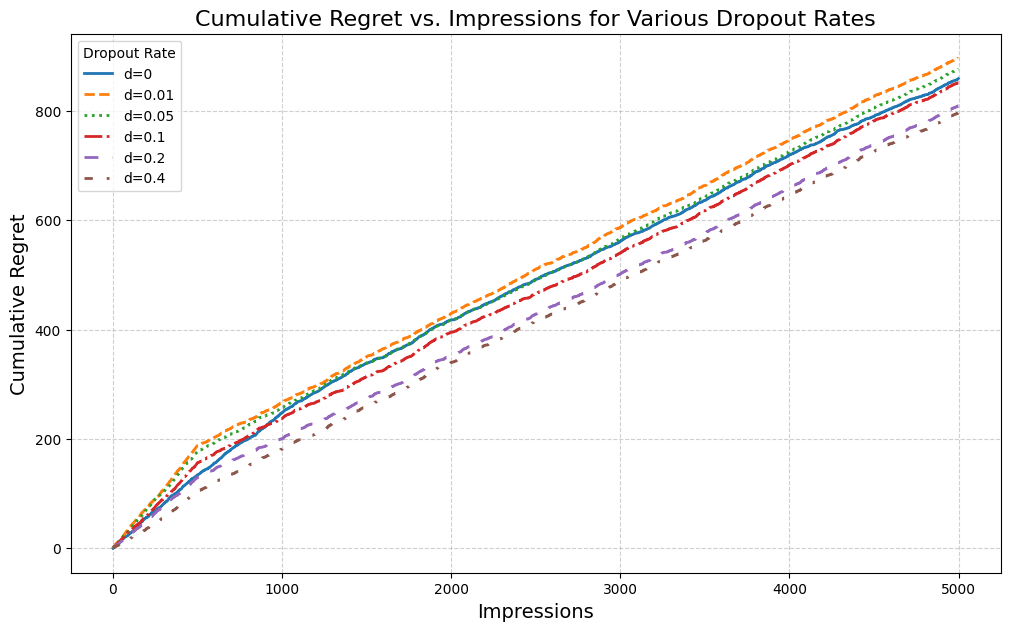

In [ ]:
# Define a list of Matplotlib linestyles to mimic the required variation
# These correspond roughly to the requested styles: solid, dash, dot, dashdot, etc.
linestyles = [
    'solid',      # Equivalent to 'solid'
    '--',         # Equivalent to 'dash'
    ':',          # Equivalent to 'dot'
    '-.',         # Equivalent to 'dashdot'
    (0, (5, 5)),  # Long dash (5 points on, 5 points off)
    (0, (3, 5, 1, 5)), # Long dash dot (3 points on, 5 off, 1 on, 5 off)
]

# Set up the figure and axes
plt.figure(figsize=(12, 7))

# Iterate through each column (each dropout level experiment)
for i, col in enumerate(df_cbandits.columns):
    # Determine the linestyle cyclically
    style = linestyles[i % len(linestyles)]

    # Plot the cumulative regret for the current dropout level
    plt.plot(df_cbandits.index,
             df_cbandits[col],
             label=col.replace('dropout: ', 'd='),
             linestyle=style,
             linewidth=2)

# Set plot titles and labels
plt.title('Cumulative Regret vs. Impressions for Various Dropout Rates', fontsize=16)
plt.xlabel('Impressions', fontsize=14)
plt.ylabel('Cumulative Regret', fontsize=14)

# Add a legend to identify the lines
plt.legend(title='Dropout Rate', loc='upper left')

# Add a grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()